In [27]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys, os, re
from pathlib import Path
from typing import Optional
sys.path.append('../')

from src import *

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
})

seed = 42
np.random.seed(seed)
warnings.simplefilter(action='ignore', category=FutureWarning)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
df = pd.read_parquet("../data/all_raman_spectra.parquet")

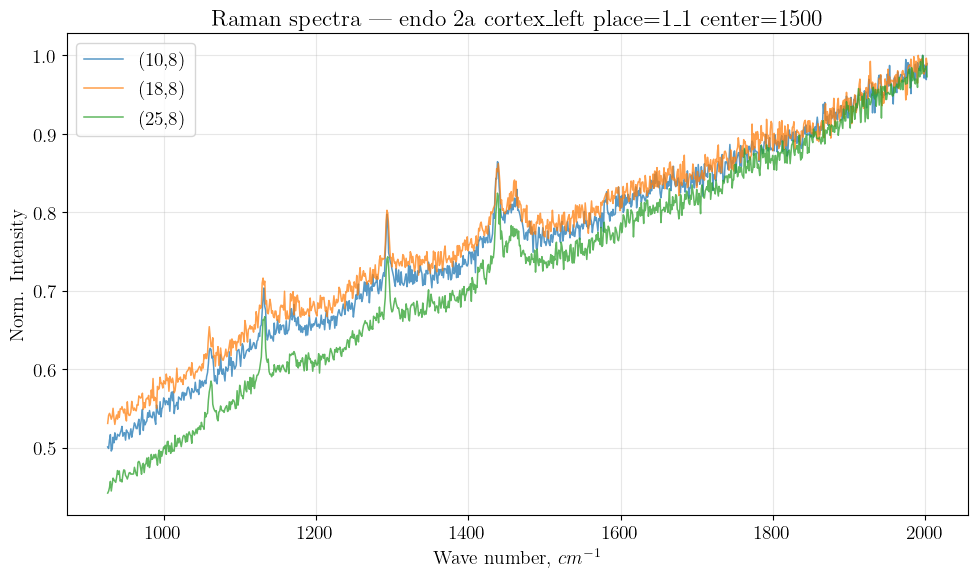

In [34]:
# 1. Из большого DataFrame — конкретные точки
plot_raman_spectra(
    df=df,
    label='cen',
    group='2a',
    center='1500',
    brain='cortex_left',
    place='1_1',                    # ← обязательно для одной карты
    points=[(10, 8), (18, 8), (25, 8)],
    normalize=True,
    wave_range=(0, 1000000)
)

✅ Загружена карта 35 × 15 точек


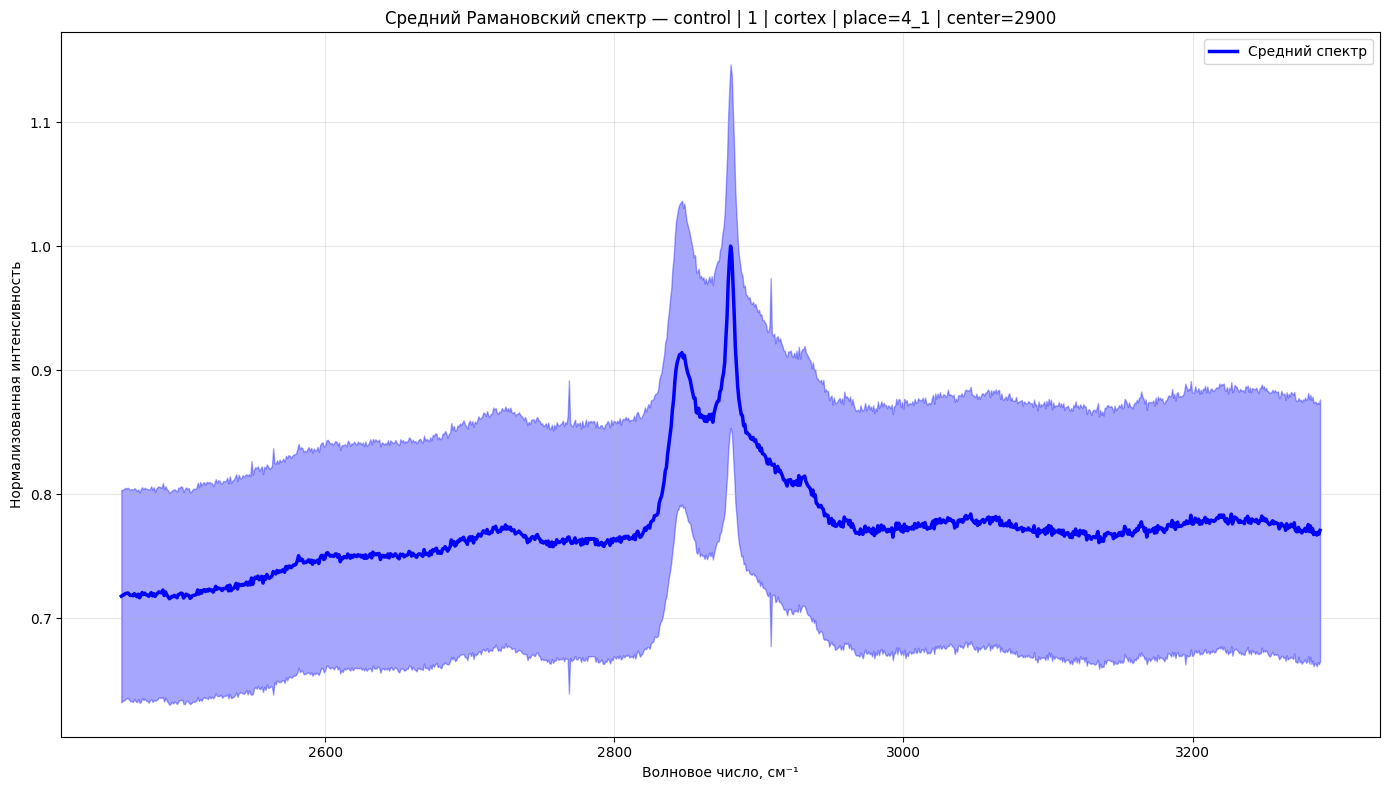

✅ Загружена карта 35 × 15 точек


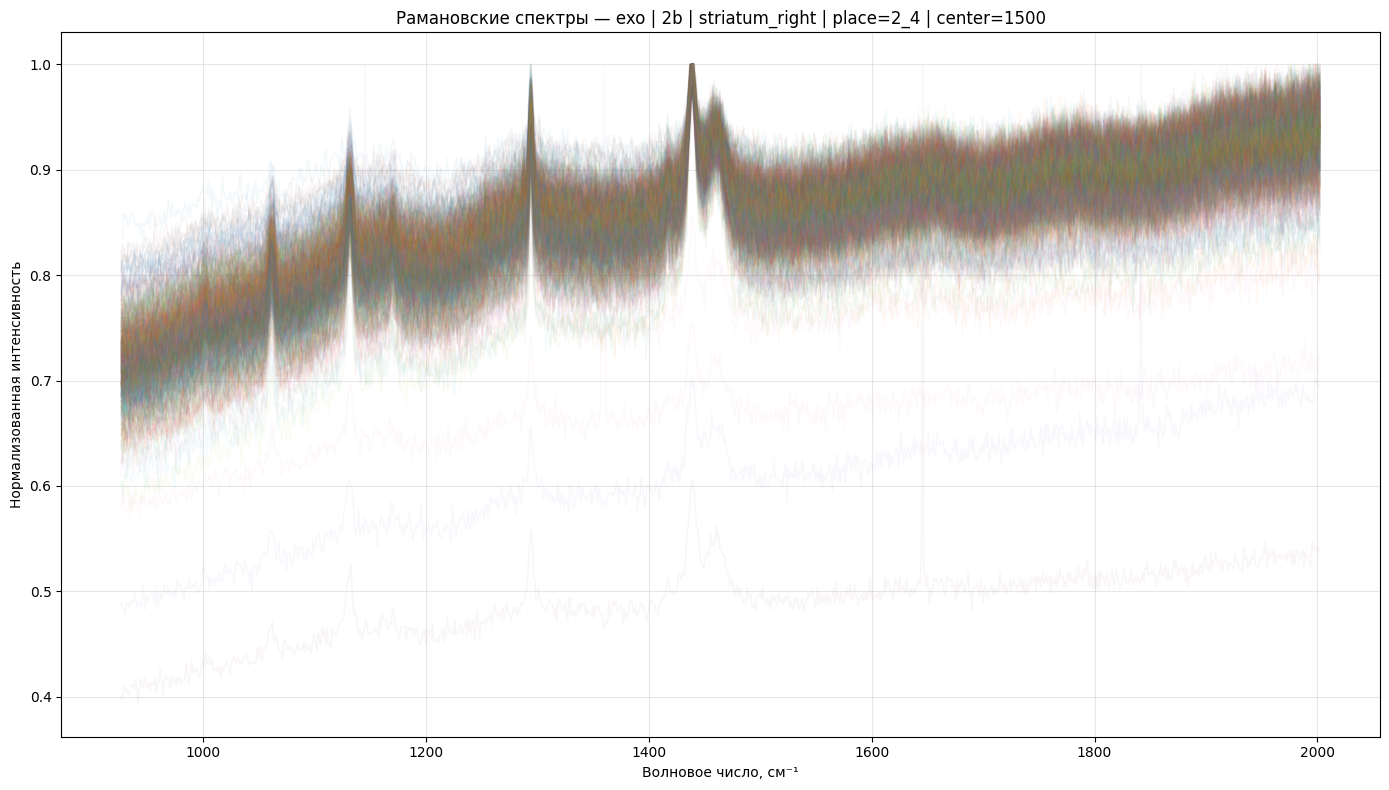

In [5]:
# 2. Средний спектр всей карты (с разбросом)
plot_raman_spectra(
    df=df,
    label='control',
    group='1',
    center='2900',
    brain='cortex',
    place='4_1',
    plot_average=True,
    normalize=True
)

# 4. Все спектры карты (плотный график)
plot_raman_spectra(
    df=df,
    label='exo',
    group='2b',
    center='1500',
    brain='striatum_right',
    place='2_4',
    alpha=0.05
)

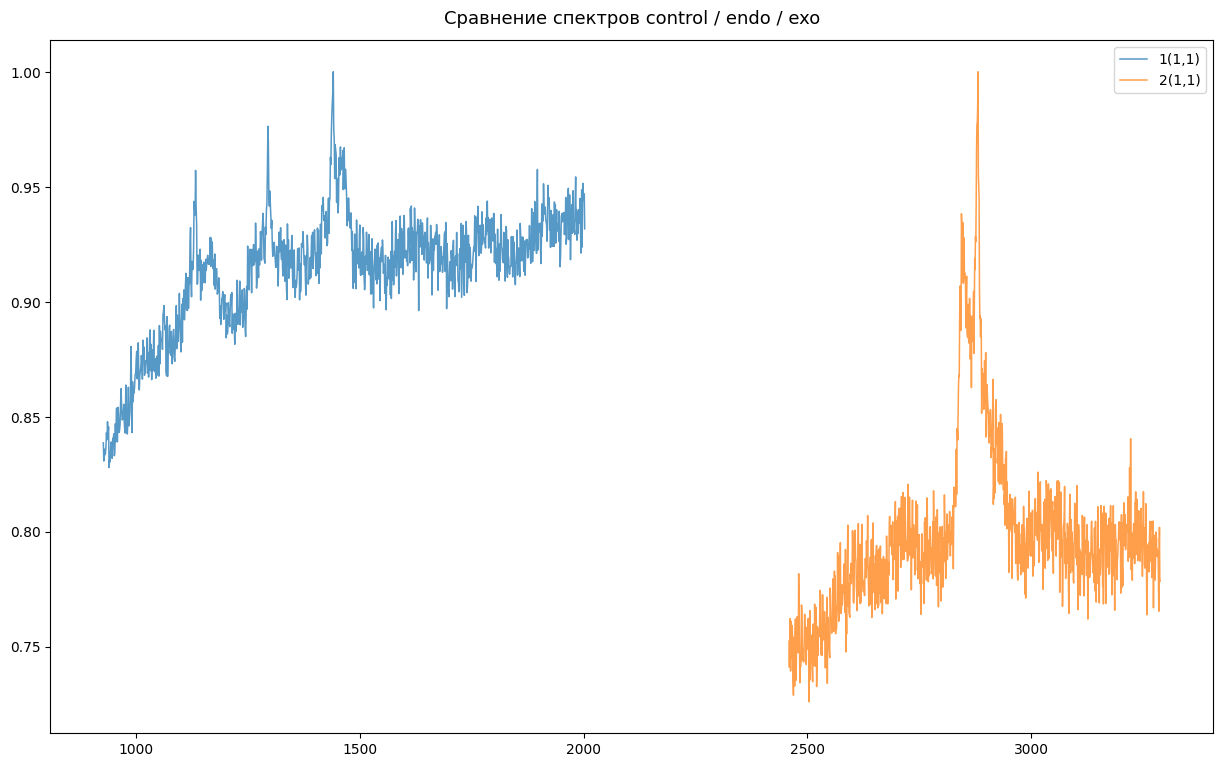

In [16]:
fig, ax = plt.subplots(figsize=(15, 9))

plot_raman_spectra(
    df=df,
    label="control", group="1", center="1500", brain="cortex", place="4_1",
    points=[(1,1)],
    ax=ax,
    label_prefix="1",
    color="C0",
    normalize=True,
)

plot_raman_spectra(
    df=df,
    label="control", group="1", center="2900", brain="cortex", place="4_1",
    points=[(1,1)],
    ax=ax,
    label_prefix="2",
    color="C1",
    normalize=True,
)

ax.set_title("Сравнение спектров control / endo / exo", fontsize=13, pad=12)
ax.legend()
plt.show()